In [1]:

library(tidyverse)
library(deSolve)
library(ggplot2)

# -------------------------------------------------------------------------
# functions for solving Lotka-Volterra systems
source("GLV_functions.R")


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


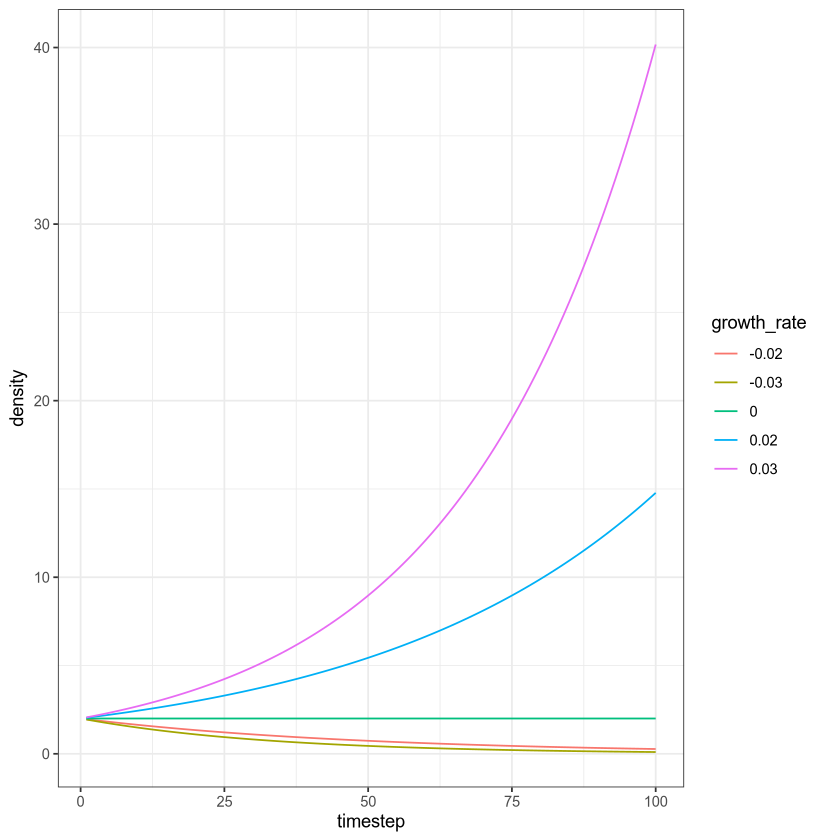

In [2]:

# -------------------------------------------------------------------------
# exponential growth

r <- c(-0.03, -0.02, 0, 0.02, 0.03)
N0 <- 2
time <- seq(1,100,1)
cont.mat <- sapply(r, function(r) N0 * exp(r * time))
cont.df <- as.data.frame(cont.mat)
names(cont.df) <- as.character(r)
cont.df$timestep <- time
cont.long <- cont.df %>% pivot_longer(cols = 1:5, names_to = "growth_rate",
                                      values_to = "density") 

ggplot(cont.long,aes(x = timestep, y = density, group = growth_rate)) + 
  geom_line(aes(color = growth_rate)) + 
  theme_bw() +
  NULL


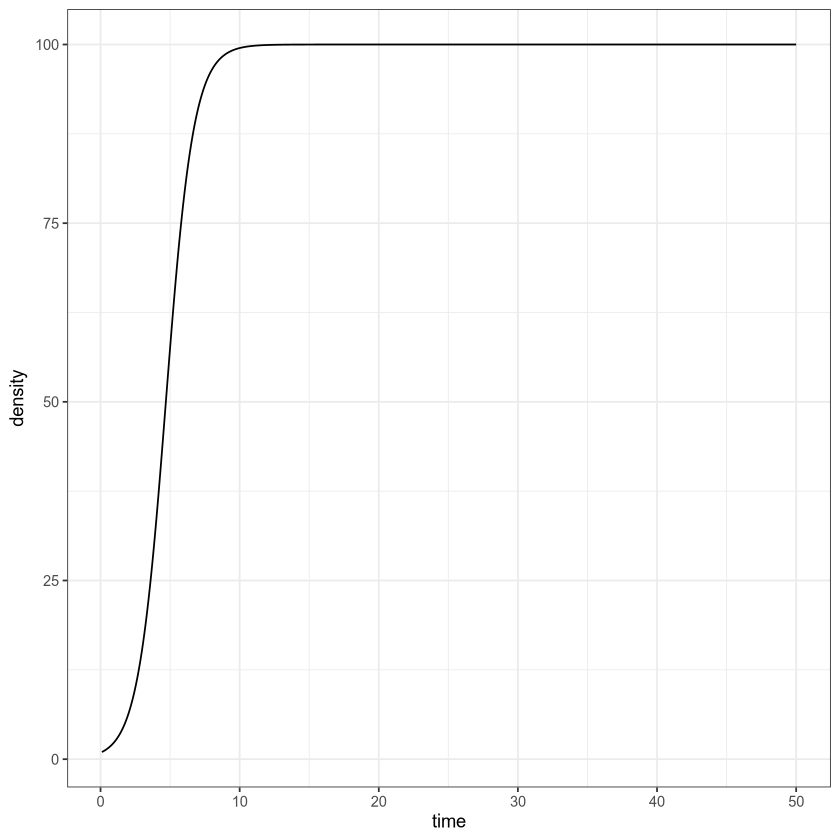

In [3]:

# -------------------------------------------------------------------------
# logistic growth

logistic_growth <- function(times, y, parms) {
  n <- y[1]
  r <- parms[1]
  K <- parms[2]
  dN.dt <- r * n * (1 - n/K)
  return(list(c(dN.dt)))
}


prms <- c(r = 1, K = 100)
init.N <- c(1)
t.s <- seq(0.1, 50, by = 0.01)
out <- ode(y = init.N, times = t.s, logistic_growth, parms = prms)
out.df <- as.data.frame(out)
names(out.df)[2] <- "density"

ggplot(out.df, aes(x = time, y = density)) + 
  geom_line() +
  theme_bw() +
  NULL


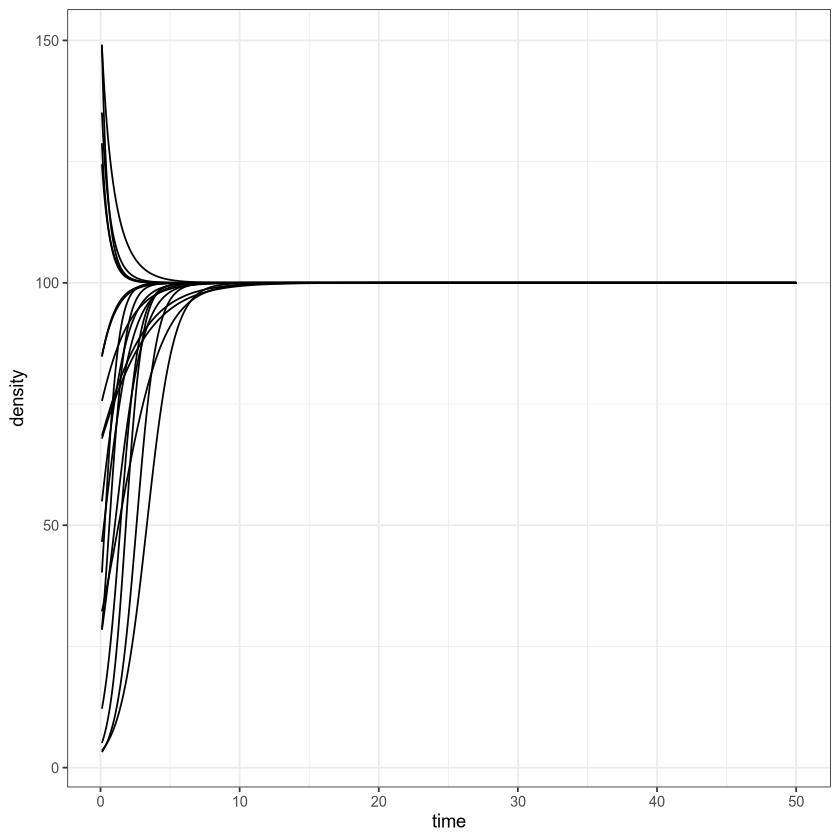

In [4]:

# different growth rates and initial conditions
out.list <- list()
for (i in 1:20) {
  y <- runif(n = 1, min = 0, max = 150)
  prms <- c(r = runif(1, 0.01, 2), K = 100)
  i.out <- as.data.frame(ode(y, times = t.s, logistic_growth, prms))
  names(i.out)[2] <- "density"
  i.out$replicate <- i
  out.list[[i]] <- i.out
}
out.df <- bind_rows(out.list)

ggplot(out.df, aes(x = time, y = density, group = replicate)) + 
  geom_line() +
  theme_bw() +
  NULL


[1] -0.08333333  0.25000000 -0.08333333


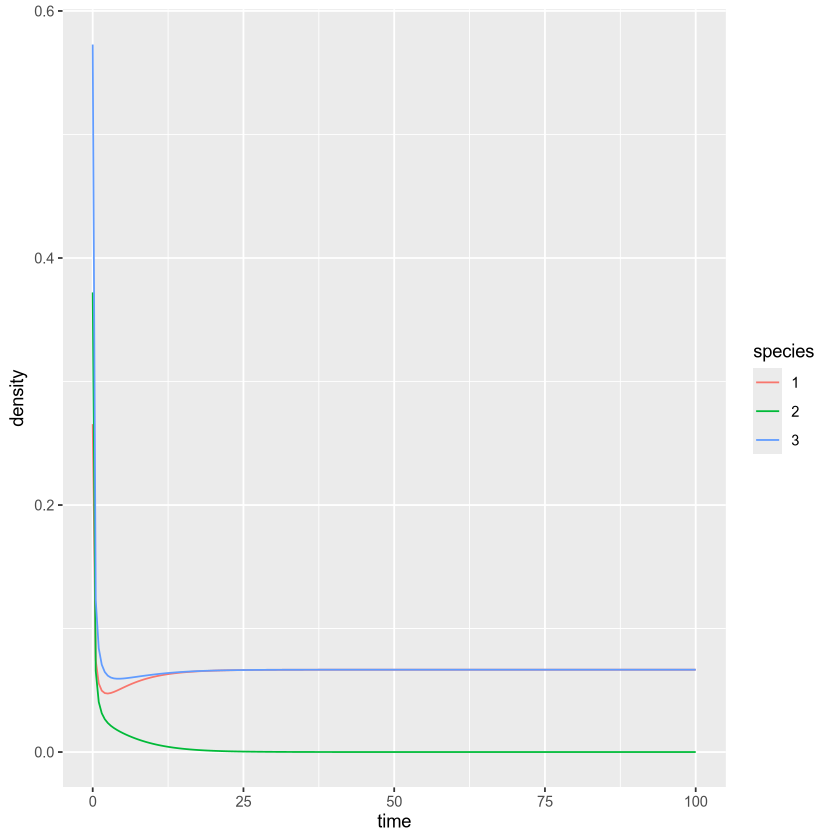

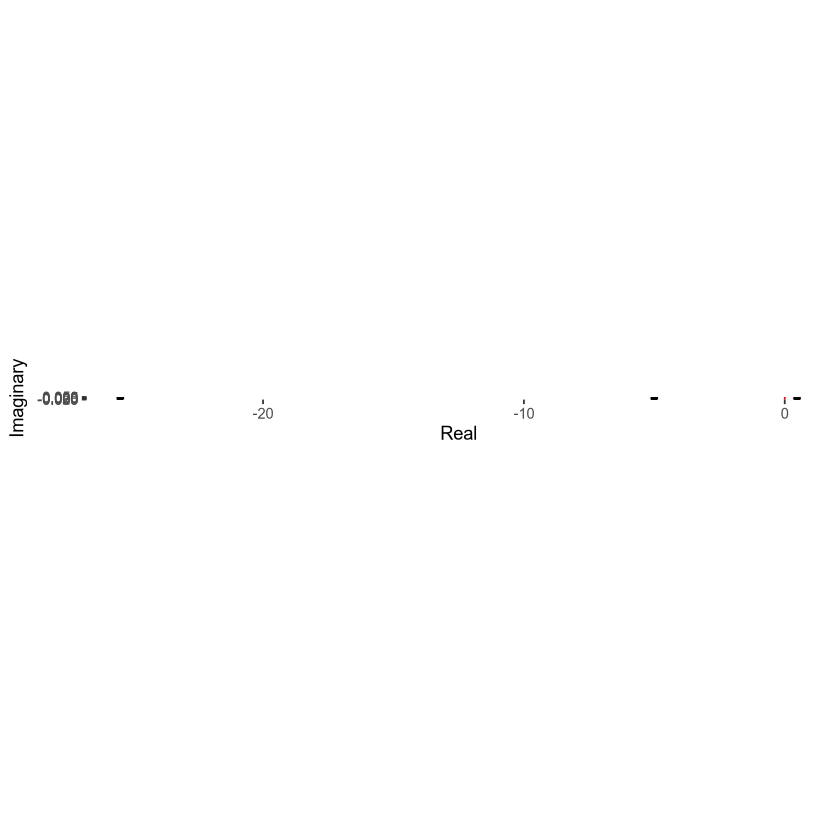

In [5]:

# -------------------------------------------------------------------------
# Lotka-Volterra systems

# unstable system

set.seed(1) # for reproducibility
r_1 <- rep(1, 3)
A_1 <- -matrix(c(10, 9, 5, 
                 9, 10, 9, 
                 5, 9, 10), 3, 3, byrow = TRUE)
# check the existence of feasible equilibrium
# all eigenvalues <0?
print(solve(A_1, -r_1)) # not feasible
x0_1 <- runif(3)
res_1 <- integrate_GLV(r_1, A_1, x0_1)
lv1 <- ggplot(data = res_1) +
  aes(x = time, y = density, colour = species) + #ylim(0,1e5) +
  geom_line()
lv1
plot_eigenvalues(A_1)


[1] 0.1661130 0.3654485 0.4817276


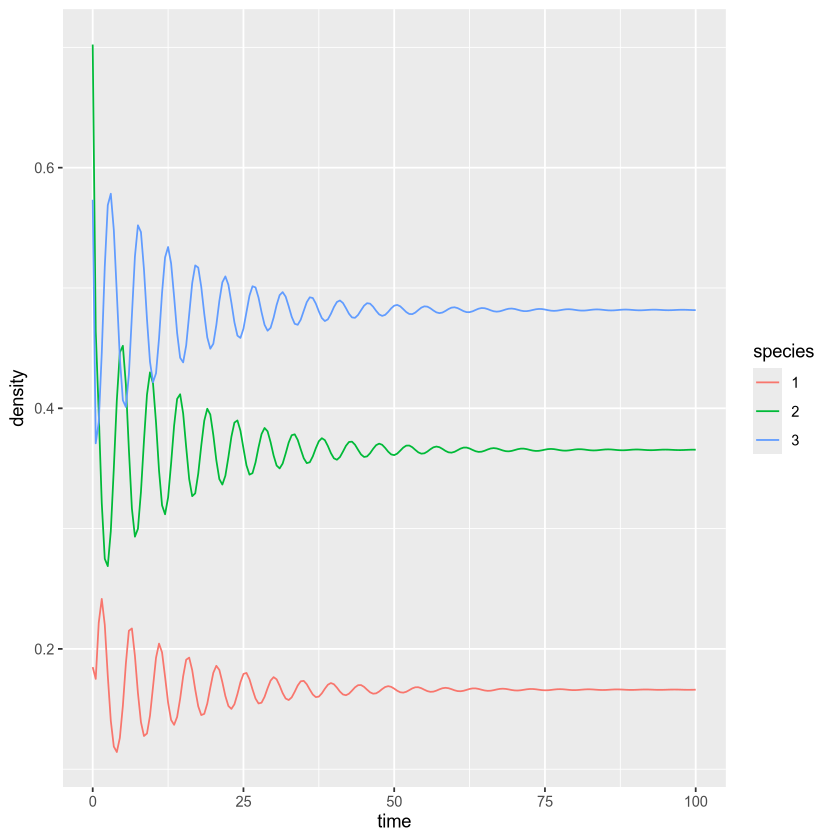

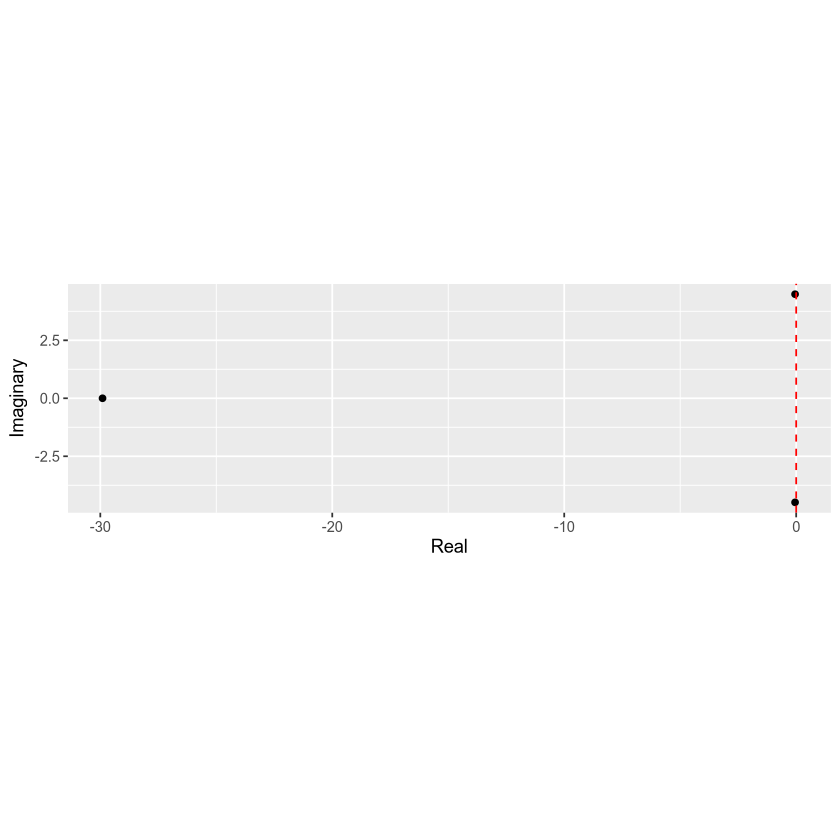

In [6]:

# -------------------------------------------------------------------------
# stable

set.seed(2) # for reproducibility
r_2 <- rep(10, 3)
A_2 <- -matrix(c(10, 7, 12, 
                 15, 10, 8, 
                 7, 11, 10), 3, 3, byrow = TRUE)
# check the existence of feasible equilibrium
print(solve(A_2, -r_2)) # feasible
x0_2 <- runif(3)
res_2 <- integrate_GLV(r_2, A_2, x0_2)
lv2 <- ggplot(data = res_2) +
  aes(x = time, y = density, colour = species) + #ylim(0,1e5) +
  geom_line()

lv2
plot_eigenvalues(A_2)


[1] 0.05714286 0.01428571 0.02857143


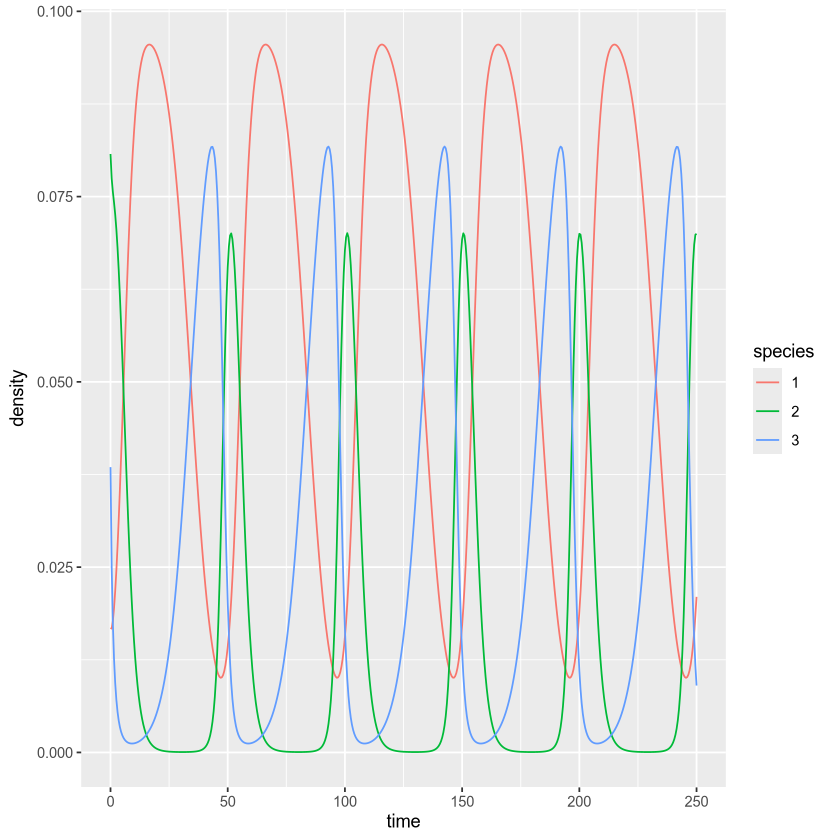

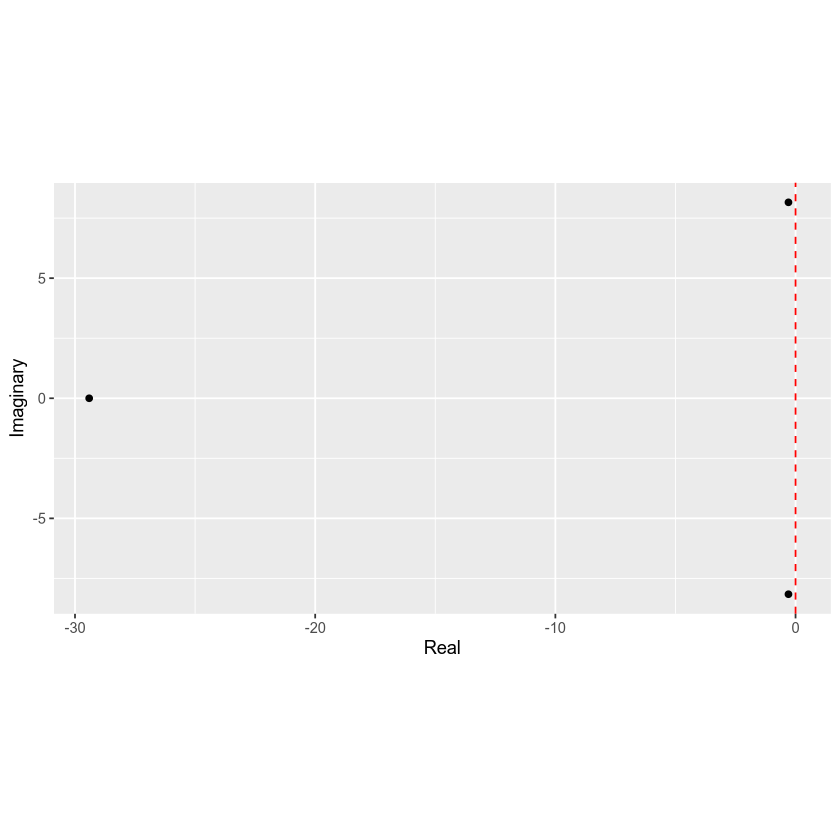

In [7]:

# -------------------------------------------------------------------------
# stable limit cycles

set.seed(3) # for reproducibility
r_3 <- rep(1, 3)
A_3 <- -matrix(c(10, 6, 12, 
                 14, 10, 2, 
                 8, 18, 10), 3, 3, byrow = TRUE)
# check the existence of feasible equilibrium
print(solve(A_3, -r_3)) # feasible
x0_3 <- 0.1 * runif(3)
res_3 <- integrate_GLV(r_3, A_3, x0_3, maxtime = 250)
lv3 <- ggplot(data = res_3) +
  aes(x = time, y = density, colour = species) + #ylim(0,1e5) +
  geom_line()

lv3
plot_eigenvalues(A_3)


[1] 0.3013030 0.4586546 0.1307655 0.3557416


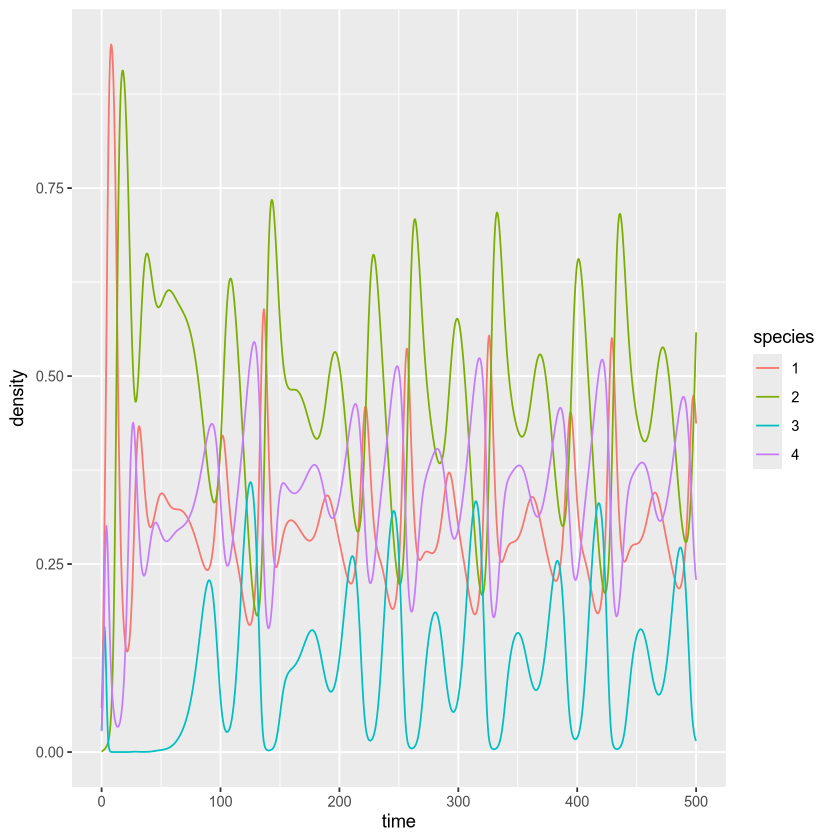

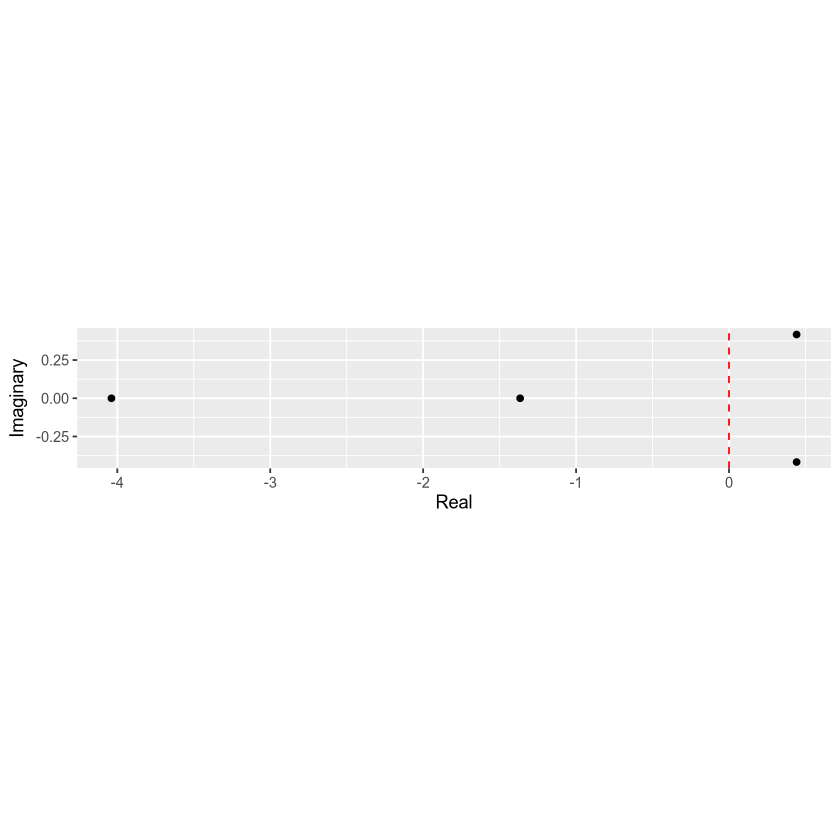

In [8]:

# -------------------------------------------------------------------------
# chaos

set.seed(4) # for reproducibility
r_4 <- c(1, 0.72, 1.53, 1.27)
A_4 <- -matrix(c(1, 1.09, 1.52, 0, 
                 0, 0.72, 0.3168, 0.9792, 
                 3.5649, 0, 1.53, 0.7191,
                 1.5367, 0.6477, 0.4445, 1.27), 4, 4, byrow = TRUE)
# check the existence of feasible equilibrium
print(solve(A_4, -r_4)) # feasible
x0_4 <- 0.1 * runif(4)
res_4 <- integrate_GLV(r_4, A_4, x0_4, maxtime = 500)
lv4 <- ggplot(data = res_4) +
  aes(x = time, y = density, colour = species) + #ylim(0,1e5) +
  geom_line()

lv4
plot_eigenvalues(A_4)


 [1] -1.3077588  1.3601734 -5.8017153  2.2733380 10.9126571 -1.9505644
 [7]  0.4948470  0.7732450 -0.9250537 -3.0333557  0.2199529 -5.3313008
[13]  4.1211425  2.6281404 -1.3261034  2.8473244  2.3658531 -3.9536812
[19] -1.6554663  1.6169267  0.2250462 -1.8705313 -0.4441928  2.3365828
[25]  0.1393047


time,species,density
<dbl>,<chr>,<dbl>
0.0,1,0.1000000
0.5,1,0.1513630
1.0,1,0.2207387
1.5,1,0.3076016
2.0,1,0.4071755
2.5,1,0.5107606


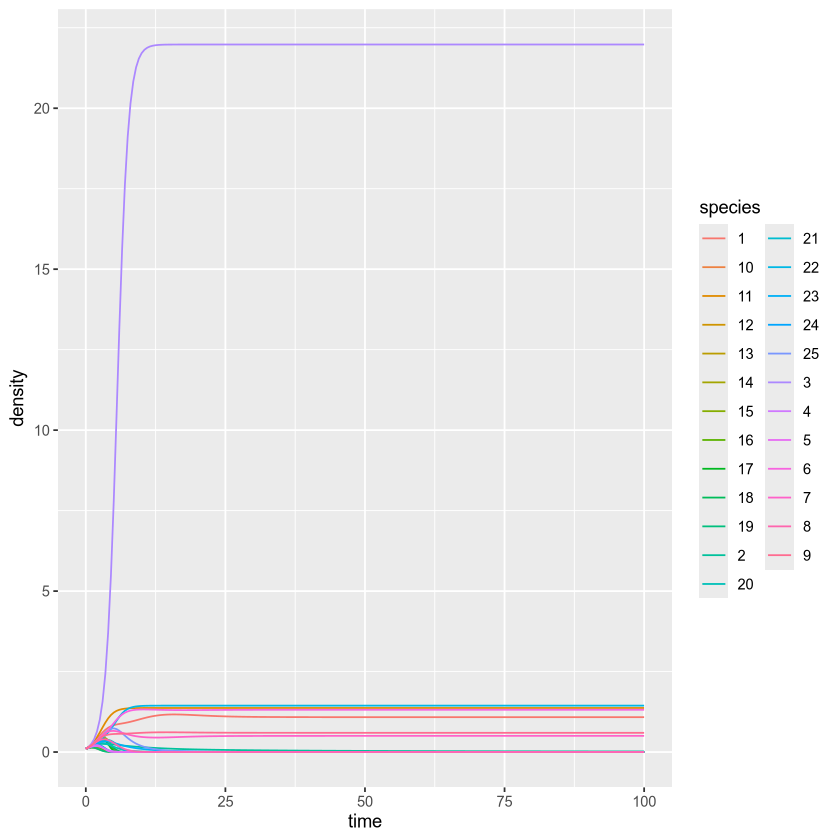

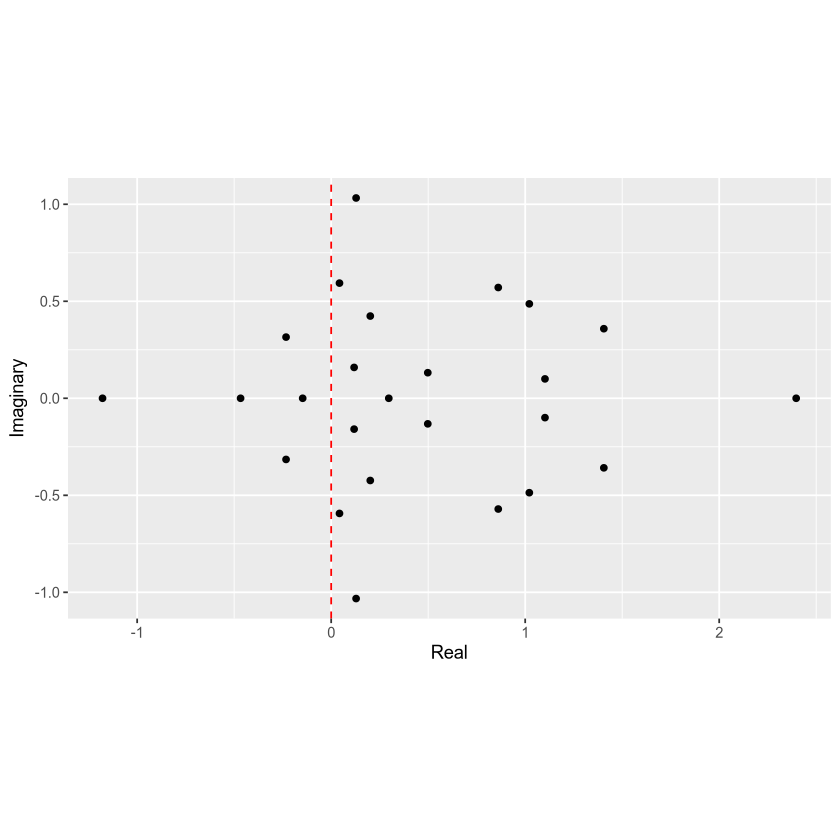

In [14]:

# -------------------------------------------------------------------------
# a slightly more ecologically realistic interaction matrix

# richness
S <- 25
# connectance
c <- 0.2
# generate interaction matrix
A_5 <- horizontal_community_matrix(S,c)
# growth rates
r <- rep(1,S)
# initial abundances
x0 <- rep(.1,S)

# solve the system
lv.dynamics <- integrate_GLV(r = r,
                             A = A_5,
                             x0 = x0,
                             positive.competition = TRUE)

print(solve(A_5, -r)) # quite a few species go extinct

# check the resulting dynamics
head(lv.dynamics)

# plot
pl <- ggplot(data = lv.dynamics) +
    aes(x = time, y = density, colour = species) + #ylim(0,1e5) +
    geom_line()

pl
plot_eigenvalues(A_5)

 [1] -2.457968e-01 -5.020685e-01  1.417795e-01 -4.884440e-01  3.469752e-01
 [6] -2.864201e-01 -6.183879e-01 -7.480553e-01 -6.583594e-01 -6.143286e-01
[11] -8.882306e-01 -6.372451e-01 -5.413578e-01 -7.800385e-01  1.419459e+00
[16] -9.140321e-01  2.011474e-01 -1.601924e-05 -1.666116e-01  4.190317e-01
[21]  2.754853e-01 -1.299970e-01 -5.939230e-01 -9.868662e-01 -6.353900e-01


time,species,density
<dbl>,<chr>,<dbl>
0.0,1,0.1000000
0.5,1,0.1367182
1.0,1,0.1764684
1.5,1,0.2155884
2.0,1,0.2516800
2.5,1,0.2843855


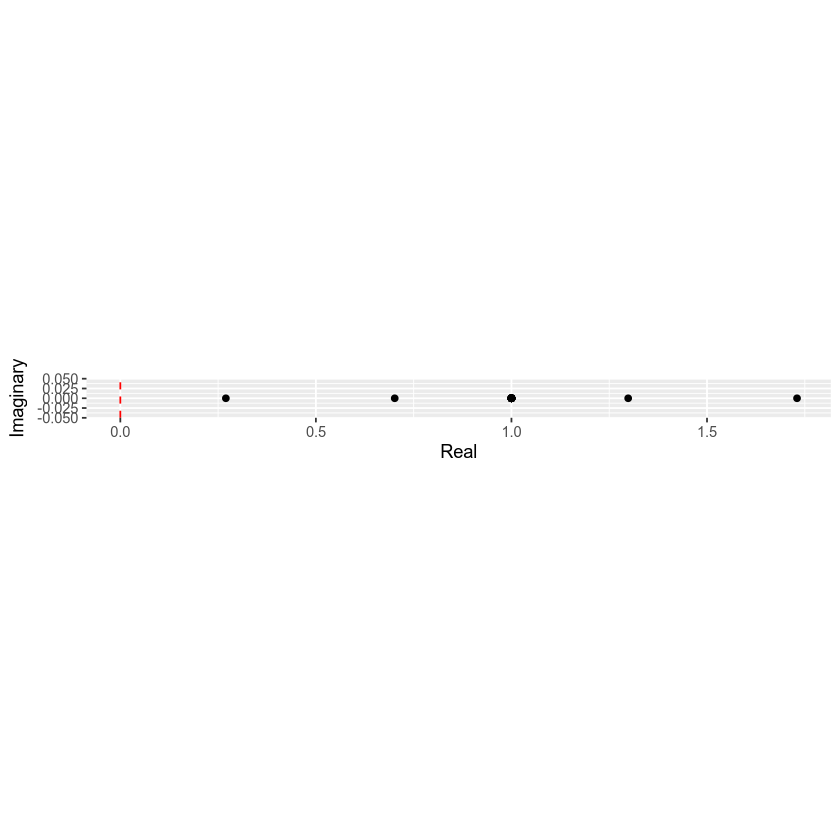

time,species,density
<dbl>,<chr>,<dbl>
0.0,1,0.1000000
0.5,1,0.1367182
1.0,1,0.1764684
1.5,1,0.2155884
2.0,1,0.2516800
2.5,1,0.2843855
3.0,1,0.3147059
3.5,1,0.3438673
4.0,1,0.3726287


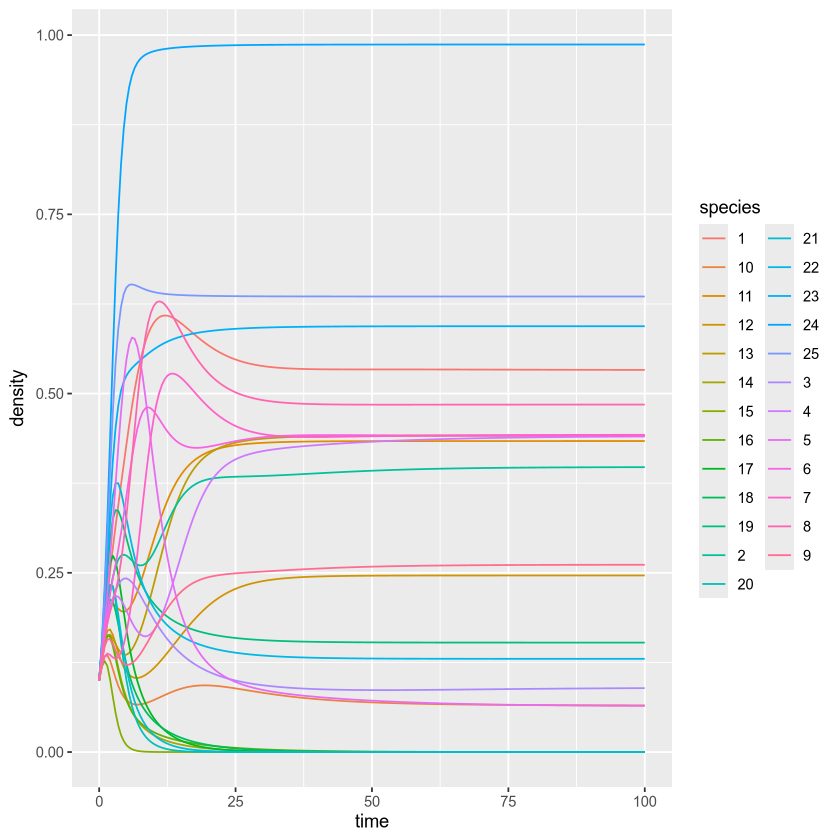

In [20]:

# -------------------------------------------------------------------------

# a binary food web
S <- 25
c <- 0.2
A_6 <- niche(S,c)

# set interaction strengths
A_6[A_6 == 1] <- runif(sum(A_6 == 1))
# intraspecific strength. Should this be zero/one, or something else?
diag(A_6) <- 1
plot_eigenvalues(A_6)

# growth rates
r <- rep(1,S)
# initial abundances
x0 <- rep(.1,S)

# solve the system
lv.dynamics <- integrate_GLV(r = r,
                             A = A_6,
                             x0 = x0,
                             positive.competition = TRUE)

print(solve(A_6, -r)) # quite a few species go extinct

# check the resulting dynamics
head(lv.dynamics)

# plot
pl <- ggplot(data = lv.dynamics) +
    aes(x = time, y = density, colour = species) + #ylim(0,1e5) +
    geom_line()

pl

lv.dynamics